In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator
import gzip
import re
import os
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['pdf.use14corefonts'] = True
plt.rcParams['path.simplify'] = True
plt.rcParams['path.simplify_threshold'] = 0.1
plt.rcParams['agg.path.chunksize'] = 0
# ========================= 配置参数 =========================
SEG_FILES = [
    "DMSO-Mock.seg",
    "DMSO-BMH21.seg",
    "APH-Mock.seg",
    "APH-BMH21.seg"
]
GTF_FILE = "/home/DDR/GTF/Homo_sapiens.GRCh38.112.gtf"   # hg38 GTF 文件（支持 .gtf 或 .gtf.gz）

# 待展示的染色体区域
CHROM = "chr16"
START = int(82509931)
END = int(83719308)

# 拷贝数颜色
CMAP = plt.cm.RdBu_r
VMAX = 1.0      # 最大值
VMIN = -1.0     # 最小值

def read_seg(filepath):
    df = pd.read_csv(filepath, sep='\t', header=1,
                     names=['ID', 'chrom', 'loc.start', 'loc.end', 'num.mark', 'seg.mean'])
    df['chrom'] = df['chrom'].astype(str)

    numeric_cols = ['loc.start', 'loc.end', 'num.mark', 'seg.mean']
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    df.dropna(subset=['loc.start', 'loc.end', 'seg.mean'], inplace=True)
    df['loc.start'] = df['loc.start'].astype(int)
    df['loc.end'] = df['loc.end'].astype(int)
    df['seg.mean'] = df['seg.mean'].astype(float)
    df = df[df['chrom'] == CHROM]
    df = df[(df['loc.start'] < END) & (df['loc.end'] > START)]
    
    return df

seg_dfs = []
for f in SEG_FILES:
    if not os.path.exists(f):
        raise FileNotFoundError(f"Seg 文件不存在: {f}")
    seg_dfs.append(read_seg(f))
    print(f"Loaded {f}: {len(seg_dfs[-1])} overlapping segments")

Loaded DMSO-Mock.seg: 3 overlapping segments
Loaded DMSO-BMH21.seg: 3 overlapping segments
Loaded APH-Mock.seg: 3 overlapping segments
Loaded APH-BMH21.seg: 3 overlapping segments


In [12]:
# ========================= 解析 GTF 文件 =========================
def parse_gtf(gtf_path, chrom, start, end):
    """
    从 GTF 文件中提取指定区域内的基因和外显子。
    返回两个字典：
        genes: {gene_id: {'name': , 'strand': , 'exons': [(start, end), ...]}}
    """
    open_fn = gzip.open if gtf_path.endswith('.gz') else open
    
    genes = {}
    with open_fn(gtf_path, 'rt') as f:
        for line in f:
            if line.startswith('#'):
                continue
            parts = line.strip().split('\t')
            if len(parts) < 9:
                continue
            chrom_gtf = "chr" + parts[0]
            if chrom_gtf != chrom:
                continue
            feature = parts[2]
            if feature not in ['gene', 'exon']:
                continue
            pos_start = int(parts[3])
            pos_end = int(parts[4])

            if pos_end < start or pos_start > end:
                continue
            strand = parts[6]
            attr_str = parts[8]
            # 提取 gene_id
            gene_id_match = re.search(r'gene_id "([^"]+)"', attr_str)
            if not gene_id_match:
                continue
            gene_id = gene_id_match.group(1)
            # 提取 gene_name
            gene_name_match = re.search(r'gene_name "([^"]+)"', attr_str)
            gene_name = gene_name_match.group(1) if gene_name_match else gene_id

            if gene_name.startswith("ENSG"):
                continue
                
            if feature == 'gene':
                # 记录基因基本信息
                if gene_id not in genes:
                    genes[gene_id] = {'name': gene_name, 'strand': strand, 'exons': []}
                else:
                    pass
            elif feature == 'exon':
                if gene_id not in genes:
                    genes[gene_id] = {'name': gene_id, 'strand': strand, 'exons': []}
                genes[gene_id]['exons'].append((pos_start, pos_end))

    for gid in genes:
        exs = sorted(set(genes[gid]['exons']))
        genes[gid]['exons'] = exs
    return genes

print("Parsing GTF file (this may take a few seconds)...")
genes_in_region = parse_gtf(GTF_FILE, CHROM, START, END)
print(f"Found {len(genes_in_region)} gene(s) in region {CHROM}:{START}-{END}")
for gid, info in genes_in_region.items():
    print(f"  {info['name']} ({info['strand']})")

Parsing GTF file (this may take a few seconds)...
Found 5 gene(s) in region chr16:82509931-83719308
  CDH13 (+)
  MIR8058 (+)
  RN7SL134P (+)
  CDH13-AS1 (-)
  MIR3182 (+)


In [13]:
SELECTED_GENES = ["CDH13"]
# ========================= 按指定基因过滤 =========================
if SELECTED_GENES:
    filtered = {}
    for gid, info in genes_in_region.items():
        if info['name'] in SELECTED_GENES:
            filtered[gid] = info
    found_names = {info['name'] for info in filtered.values()}
    missing = set(SELECTED_GENES) - found_names
    if missing:
        print(f"Warning: These genes were not found in region: {missing}")
    genes_in_region = filtered
    print(f"After filter, {len(genes_in_region)} gene(s) remain: {list(found_names)}")
else:
    print("No gene filter applied. All eligible genes will be shown.")

for gid, info in genes_in_region.items():
    print(f"  {info['name']} ({info['strand']})")

After filter, 1 gene(s) remain: ['CDH13']
  CDH13 (+)


In [14]:
# 拷贝数颜色
CMAP = plt.cm.RdBu_r
VMAX = 0.5
VMIN = -0.5

/tmp/ipykernel_3371795/1698219769.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


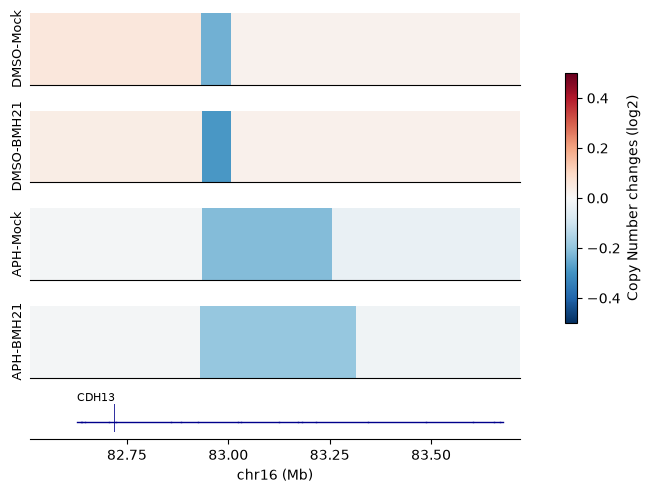

In [15]:
sample_names = [os.path.splitext(os.path.basename(f))[0] for f in SEG_FILES]

# ========================= 绘图 =========================
fig, axs = plt.subplots(5, 1, figsize=(6, 5),
                        gridspec_kw={'height_ratios': [1, 1, 1, 1, 0.5]},
                        sharex=True)
fig.subplots_adjust(hspace=0.2)

for ax in axs:
    ax.set_xlim(START, END)

norm = plt.Normalize(vmin=VMIN, vmax=VMAX)

# ---- 1. 绘制 4 个样本的热图行 ----
for i, (ax, df) in enumerate(zip(axs[:4], seg_dfs)):
    ax.set_ylabel(sample_names[i], fontsize=9)
    ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    # ax.spines['bottom'].set_visible(False)
    ax.set_facecolor('white')
    
    if df.empty:
        ax.set_facecolor('lightgray')
        continue
    
    for _, row in df.iterrows():
        seg_start = max(row['loc.start'], START)
        seg_end = min(row['loc.end'], END)
        width = seg_end - seg_start
        color = plt.cm.RdBu_r(norm(row['seg.mean']))
        rect = mpatches.Rectangle((seg_start, 0), width, 1,
                                  facecolor=color, edgecolor='none')
        ax.add_patch(rect)
    ax.set_ylim(0, 1)

# ---- 2. 绘制基因结构 ----
ax_gene = axs[4]
ax_gene.set_xlabel(f"{CHROM} (Mb)", fontsize=10)
ax_gene.spines['left'].set_visible(False)
ax_gene.spines['top'].set_visible(False)
ax_gene.spines['right'].set_visible(False)

gene_ids_ordered = sorted(genes_in_region.keys(), key=lambda g: genes_in_region[g]['name'])
num_genes = len(gene_ids_ordered)
ax_gene.set_ylim(0, num_genes)

for idx, gid in enumerate(gene_ids_ordered):
    info = genes_in_region[gid]
    y_center = idx + 0.5
    for ex_start, ex_end in info['exons']:
        width = ex_end - ex_start
        rect = mpatches.Rectangle((ex_start, y_center - 0.3), width, 1,
                                  facecolor='darkblue', edgecolor='none', alpha=0.8)
        ax_gene.add_patch(rect)
    if len(info['exons']) > 1:
        for j in range(len(info['exons']) - 1):
            x1 = info['exons'][j][1]
            x2 = info['exons'][j+1][0]
            ax_gene.plot([x1, x2], [y_center, y_center], color='darkblue', linewidth=1.0)
    label_x = info['exons'][0][0] if info['exons'] else (START + END)/2
    ax_gene.text(label_x, y_center + 0.5, info['name'], fontsize=8,
                 va='bottom', ha='left', rotation=0, color='black')

import matplotlib.ticker as ticker
ax_gene.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"{x/1e6:.2f}"))
ax_gene.xaxis.set_major_locator(ticker.MaxNLocator(nbins=6))

ax_gene.yaxis.set_visible(False)

# ---- 3. 颜色条 ----
cbar_ax = fig.add_axes([0.95, 0.35, 0.02, 0.5])
sm = plt.cm.ScalarMappable(cmap=CMAP, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Copy Number changes (log2)', fontsize=10)

# 保存并显示
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.savefig("CDH13.pdf", dpi=300, bbox_inches='tight')
plt.show()